# Лабораторная работа № 5

Так как методичка старая, пришлось обновлять её и переделывать код

В задании ещё говорилось не использовать GPU, но я думаю, моя видеокарта справится лучше с этой задачей, чем CPU

## Библиотеки

In [1]:
import os
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ["DISPLAY"] = ":1"  # создание виртуального дисплея для рисования изображения, если нет монитора
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
import torch
import torch.nn as nn
import torch.nn.functional as F

I0000 00:00:1774106780.405324  807316 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


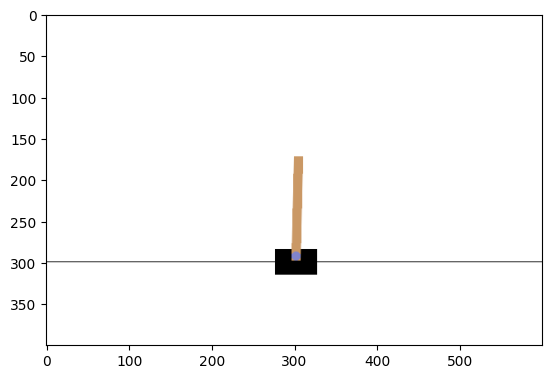

In [2]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
env.reset()
n_actions = int(env.action_space.n)  # int() иначе tensorflow ругается
state_dim = env.observation_space.shape
plt.imshow(env.render())

## Tensorflow

### Сеть

In [3]:
network = keras.models.Sequential([
    L.Input(shape=state_dim),  # входной слой имеет такую размерность, сколько состояний
    L.Dense(64, activation='relu'),  # два плотных слоя для обучения
    L.Dense(64, activation='relu'),
    L.Dense(n_actions, activation='linear')  # так как нужно предсказывать q-значения без нелинейности
])

I0000 00:00:1774106784.409621  807316 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2160 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Выбор действия с эпсилон-жадной политикой. Аналогия из 4 лабораторной работы

In [4]:
state = env.reset()[0]
q_values = network.predict(state[None], verbose=0)[0]  # вынесли за функцию, чтобы программа быстрее работала, т.к. q не меняются в тесте

def get_action(state, epsilon=0):
    if np.random.uniform(0, 1) < epsilon:
        return np.random.randint(n_actions)  # случайное действие
    
    return np.argmax(q_values)  # иначе выбираем действие, для которого наибольший q

I0000 00:00:1774106785.293003  807399 service.cc:153] XLA service 0x7f9e0c02e300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774106785.293023  807399 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1774106785.299401  807399 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774106785.322176  807399 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1774106785.660730  807399 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Проверка, что модель отображает состояние s -> \[Q(s,a0),..., Q(s, a_last)]

In [5]:
assert network.output_shape == (None, n_actions)

Проверка, что q-значения предсказываются без нелинейности

In [6]:
assert network.layers[-1].activation == keras.activations.linear

Проверка эпсилон-жадных исследований

In [7]:
assert np.shape(get_action(state)) == ()  # проверка, что возвращается только 1 действие

In [8]:
for epsilon in [0.0, 0.1, 0.5, 1.0]:
    state_frequencies = np.bincount([get_action(state, epsilon) for i in range(10000)], minlength=n_actions)
    best_action = state_frequencies.argmax()
    
    assert abs(state_frequencies[best_action] - 10000 * (1 - epsilon + epsilon / n_actions)) < 200

    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] - 10000 * (epsilon / n_actions)) < 200

    print(f"Epsilon = {epsilon}, tests passed")

Epsilon = 0.0, tests passed
Epsilon = 0.1, tests passed
Epsilon = 0.5, tests passed
Epsilon = 1.0, tests passed


Переписываем get_action(), т.к. теперь уже не тест

In [9]:
def get_action(state, epsilon=0):
    if np.random.uniform(0, 1) < epsilon:
        return np.random.randint(n_actions)  # случайное действие

    state = np.array(state, dtype=np.float32)  # преобразует в batch
    
    q_values = network(state[None]).numpy()[0]  # тут numpy() чтобы быстрее работало, predict() сильно тормозит
    
    return np.argmax(q_values)  # иначе выбираем действие, для которого наибольший q

### Q-обучение через градиентный спуск

Минимизируем потери через

$$
L = \frac{1}{N}\sum_i(Q_θ(s, a) - [r(s, a) + γ · \max_{a'}Q\_(s', a')])^2
$$

Здесь

* $s$ - текущее состояние
* $a$ - действие
* $r$ - вознаграждение
* $s'$ - следующее состояние
* $γ$ - коэффициент дисконтирования
* $Q_θ$ - результат политики нейронной сети
* $Q\_$ - результат политики нейронной сети, но через него не будут распространяться градиенты для более стабильного обучения

Далее по методичке идут плейсхолдеры, но они уже давно не используются в keras, потому пришлось переписать всё для функции обучения

In [10]:
optimizer = tf.keras.optimizers.Adam(1e-4)
gamma = 0.99

@tf.function
def train_step(states, actions, rewards, next_states, dones):
    with tf.GradientTape() as tape:
        q_values = network(states)  # Q_θ(s)
        
        action_mask = tf.one_hot(actions, n_actions)
        q_values_for_actions = tf.reduce_sum(q_values * action_mask, axis=1)  # Q_θ(s, a)

        next_q_values = network(next_states)  # Q_(s', a')

        next_state_values = tf.reduce_max(next_q_values, axis=1)  # max_a Q_(s', a')

        target_q = rewards + gamma * next_state_values  # r + gamma * max_a Q_(s', a')

        target_q = tf.where(dones, rewards, target_q)  # для последнего состояния, т.к. s' не существует

        loss = tf.reduce_mean((q_values_for_actions - tf.stop_gradient(target_q)) ** 2)  # MSE потери

        assert tf.gradients(loss, [q_values_for_actions])[0] is not None  # проверка, что q-значения обновляются для выбранных действий, а не только для всех действий
        assert tf.gradients(loss, [next_q_values])[0] is None  # проверка, что не распространяется градиент для Q_ (с', а')
        assert next_q_values.shape.ndims == 2  # проверка, что значения q предсказаны для всех действий в следующем состоянии
        assert next_state_values.shape.ndims == 1  # проверка, что V (s') вычислена как максимум только по оси действий, а не по всем осям
        assert target_q.shape.ndims == 1  # проверка, что целевые значения q - это вектор
    
    grads = tape.gradient(loss, network.trainable_variables)
    optimizer.apply_gradients(zip(grads, network.trainable_variables))

    return loss

Игра с моделью

In [11]:
def generate_session(env, t_max=1000, epsilon=0, train=False):
    total_reward = 0
    state = env.reset()[0]

    for t in range(t_max):
        action = get_action(state, epsilon=epsilon)

        next_state, reward, terminated, truncated, _ = env.step(action)

        if train:
            train_step(
                states=tf.convert_to_tensor([state], dtype=tf.float32),
                actions=tf.convert_to_tensor([action], dtype=tf.int32),
                rewards=tf.convert_to_tensor([reward], dtype=tf.float32),
                next_states=tf.convert_to_tensor([next_state], dtype=tf.float32),
                dones=tf.convert_to_tensor([terminated or truncated], dtype=tf.bool),
            )

        total_reward += reward
        state = next_state

        if terminated or truncated:
            break

    return total_reward

Обучение и вывод

In [12]:
epsilon = 0.5

for i in range(1000):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]

    print(f"epoch #{i}\tmean reward = {np.mean(session_rewards):.3f}\tepsilon = {epsilon:.3f}")

    epsilon *= 0.99
    epsilon = max(epsilon, 1e-4)

    if np.mean(session_rewards) > 300:
        print("You Win!")
        break

epoch #0	mean reward = 15.430	epsilon = 0.500
epoch #1	mean reward = 13.260	epsilon = 0.495
epoch #2	mean reward = 13.370	epsilon = 0.490
epoch #3	mean reward = 14.250	epsilon = 0.485
epoch #4	mean reward = 13.670	epsilon = 0.480
epoch #5	mean reward = 13.110	epsilon = 0.475
epoch #6	mean reward = 14.230	epsilon = 0.471
epoch #7	mean reward = 13.350	epsilon = 0.466
epoch #8	mean reward = 14.110	epsilon = 0.461
epoch #9	mean reward = 14.800	epsilon = 0.457
epoch #10	mean reward = 13.350	epsilon = 0.452
epoch #11	mean reward = 15.390	epsilon = 0.448
epoch #12	mean reward = 14.320	epsilon = 0.443
epoch #13	mean reward = 20.000	epsilon = 0.439
epoch #14	mean reward = 21.050	epsilon = 0.434
epoch #15	mean reward = 30.710	epsilon = 0.430
epoch #16	mean reward = 33.650	epsilon = 0.426
epoch #17	mean reward = 36.820	epsilon = 0.421
epoch #18	mean reward = 34.230	epsilon = 0.417
epoch #19	mean reward = 50.100	epsilon = 0.413
epoch #20	mean reward = 50.480	epsilon = 0.409
epoch #21	mean reward =

## PyTorch

Всё то же самое, но теперь в PyTorch

### Сеть

In [13]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.fc1 = nn.Linear(*state_dim, 64)  # входной слой
        self.fc2 = nn.Linear(64, 64)  # плотный слой 1
        self.fc3 = nn.Linear(64, n_actions)  # плотный слой 2

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # вывод без активации

Инициализация

In [14]:
network = QNetwork(state_dim, n_actions)
optimizer = torch.optim.Adam(network.parameters(), lr=1e-4)
gamma = 0.99

Выбор действия

In [15]:
def get_action(state, epsilon=0.0):
    if np.random.uniform(0, 1) < epsilon:
        return np.random.randint(n_actions)

    state_vector = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():  # отключаем градиент вручную, чтобы не сломать обучение
        q_values = network(state_vector)

    return int(torch.argmax(q_values, dim=1).item())

Функция для обучения

In [16]:
def train_step(states, actions, rewards, next_states, dones):
    states_vector = torch.tensor(np.array(states), dtype=torch.float32)
    actions_vector = torch.tensor(np.array(actions), dtype=torch.int64)
    rewards_vector = torch.tensor(np.array(rewards), dtype=torch.float32)
    next_states_vector = torch.tensor(np.array(next_states), dtype=torch.float32)
    dones_vector = torch.tensor(np.array(dones), dtype=torch.bool)

    q_values = network(states_vector)  # Q_θ(s)
    q_values_for_actions = q_values.gather(1, actions_vector.unsqueeze(1)).squeeze(1)  # Q_θ(s, a)

    with torch.no_grad():  # отключаем градиент для Q_(s', a')
        next_q_values = network(next_states_vector)  # Q_(s', a')
        next_state_values = torch.max(next_q_values, dim=1)[0]  # max_a Q_(s', a')

        target_q = rewards_vector + gamma * next_state_values  # r + gamma * max_a Q_(s', a')
        target_q[dones_vector] = rewards_vector[dones_vector]  # для последнего состояния, т.к. s' не существует

    loss = torch.mean((q_values_for_actions - target_q) ** 2)  # MSE потери

    optimizer.zero_grad()
    loss.backward()  # обратное распространение ошибки
    optimizer.step()

    return loss.item()

Игра с моделью

In [17]:
def generate_session(env, t_max=1000, epsilon=0, train=False):
    total_reward = 0
    state = env.reset()[0]

    for t in range(t_max):
        action = get_action(state, epsilon)

        next_state, reward, terminated, truncated, _ = env.step(action)

        if train:
            train_step([state], [action], [reward], [next_state], [terminated or truncated])

        total_reward += reward
        state = next_state

        if terminated or truncated:
            break

    return total_reward

Обучение и вывод

In [18]:
epsilon = 0.5

for i in range(1000):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]

    print(f"epoch #{i}\tmean reward = {np.mean(session_rewards):.3f}\tepsilon = {epsilon:.3f}")

    epsilon *= 0.99
    epsilon = max(epsilon, 1e-4)

    if np.mean(session_rewards) > 300:
        print("You Win!")
        break

epoch #0	mean reward = 13.840	epsilon = 0.500
epoch #1	mean reward = 13.850	epsilon = 0.495
epoch #2	mean reward = 13.740	epsilon = 0.490
epoch #3	mean reward = 18.720	epsilon = 0.485
epoch #4	mean reward = 13.910	epsilon = 0.480
epoch #5	mean reward = 16.060	epsilon = 0.475
epoch #6	mean reward = 18.060	epsilon = 0.471
epoch #7	mean reward = 23.830	epsilon = 0.466
epoch #8	mean reward = 26.670	epsilon = 0.461
epoch #9	mean reward = 32.500	epsilon = 0.457
epoch #10	mean reward = 37.110	epsilon = 0.452
epoch #11	mean reward = 44.350	epsilon = 0.448
epoch #12	mean reward = 44.540	epsilon = 0.443
epoch #13	mean reward = 55.810	epsilon = 0.439
epoch #14	mean reward = 60.240	epsilon = 0.434
epoch #15	mean reward = 72.960	epsilon = 0.430
epoch #16	mean reward = 87.080	epsilon = 0.426
epoch #17	mean reward = 109.570	epsilon = 0.421
epoch #18	mean reward = 131.940	epsilon = 0.417
epoch #19	mean reward = 155.770	epsilon = 0.413
epoch #20	mean reward = 173.750	epsilon = 0.409
epoch #21	mean rewa